<a href="https://colab.research.google.com/github/reddytian/dl-learning/blob/main/day1_2_tensors_and_training_loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Days 1–2 — Tensors, Autograd, and the Training Loop

The mechanics everything else is built on. No GPU needed; the whole notebook runs on
CPU in under a minute.

**What this covers**
- Tensors, and how they differ from NumPy arrays
- `autograd` — the automatic differentiation that makes training possible
- The five-step training loop, written by hand
- Two experiments that establish the boundaries: what happens when the learning rate
  is too large, and what happens when the model is too simple

**Takeaway:** the five-step loop below is unchanged in every later notebook. Day 3
applies it to 101,770 parameters, Day 4 to 666,538, Day 5 to 11.2 million. Only the
model changes.

## 1. Tensors

A `torch.Tensor` is an n-dimensional array. Indexing, broadcasting, `.shape`, `.sum()`
all behave like NumPy, and conversion is free in both directions (the two share
memory).

Three things NumPy does not have:

1. **A device.** A tensor lives in CPU RAM or GPU memory; `.to("cuda")` moves it.
   Operations across devices raise an error.
2. **Autograd.** Every operation is recorded so gradients can be computed backwards
   through the whole chain.
3. **`float32` by default**, where NumPy defaults to `float64` — GPUs are much faster
   in 32-bit. Feeding a `float64` array from xarray straight into a layer raises a
   dtype error; cast with `.astype(np.float32)` first.

In [1]:
import torch
import numpy as np

x = torch.tensor([[1., 2.], [3., 4.]])
print(x)
print(x.shape, x.dtype)

# NumPy <-> torch, both directions (shared memory, no copy)
a = np.array([1., 2., 3.])
t = torch.from_numpy(a)
back = t.numpy()
print(t, back, t.dtype)        # note: float64, inherited from the NumPy array

# Arithmetic behaves as expected
print(x + 1)
print(x.sum())
print("cuda available:", torch.cuda.is_available())

tensor([[1., 2.],
        [3., 4.]])
torch.Size([2, 2]) torch.float32
tensor([1., 2., 3.], dtype=torch.float64) [1. 2. 3.] torch.float64
tensor([[2., 3.],
        [4., 5.]])
tensor(10.)
cuda available: False


## 2. Autograd

`requires_grad=True` tells PyTorch to record every operation applied to a tensor.
Calling `.backward()` on a scalar then walks that record in reverse and populates
`.grad` on every input.

For `y = 3x²` at `x = 1`, the derivative `dy/dx = 6x = 6`. Verify it:

In [2]:
x = torch.tensor(1.0, requires_grad=True)
y = 3 * x**2
y.backward()
print("dy/dx =", x.grad.item())        # expect 6.0

dy/dx = 6.0


This is the entire engine. A network has millions of parameters, and training calls
this same `backward()` to compute a gradient for every one of them — which direction
to move each weight to reduce the loss.

Two properties worth knowing early:

- **`.backward()` requires a scalar.** That is why training always reduces predictions
  to a single loss number first.
- **Gradients accumulate.** `.backward()` *adds* to `.grad` rather than overwriting it,
  which is why `zero_grad()` is mandatory in the loop below. (The design is
  deliberate: it enables gradient accumulation, running several small batches and
  updating once, when memory cannot hold a large batch.)

## 3. The training loop

Fitting `y = 2x + 1` from noisy samples with a single `nn.Linear(1, 1)` — two
parameters, `w` and `b`.

The loop is five steps:

1. **forward** — the model predicts
2. **loss** — measure how wrong
3. **zero_grad** — clear the previous step's gradients
4. **backward** — autograd computes new gradients
5. **step** — the optimizer updates the parameters

Everything later in this repo uses exactly this, unchanged.

Epoch   0 | loss = 16.5048
Epoch  10 | loss = 0.2183
Epoch  20 | loss = 0.1083
Epoch  30 | loss = 0.0961
Epoch  40 | loss = 0.0947
Epoch  50 | loss = 0.0945
Epoch  60 | loss = 0.0945
Epoch  70 | loss = 0.0945
Epoch  80 | loss = 0.0945
Epoch  90 | loss = 0.0945

learned: w = 2.000, b = 1.011   (true w=2, b=1)


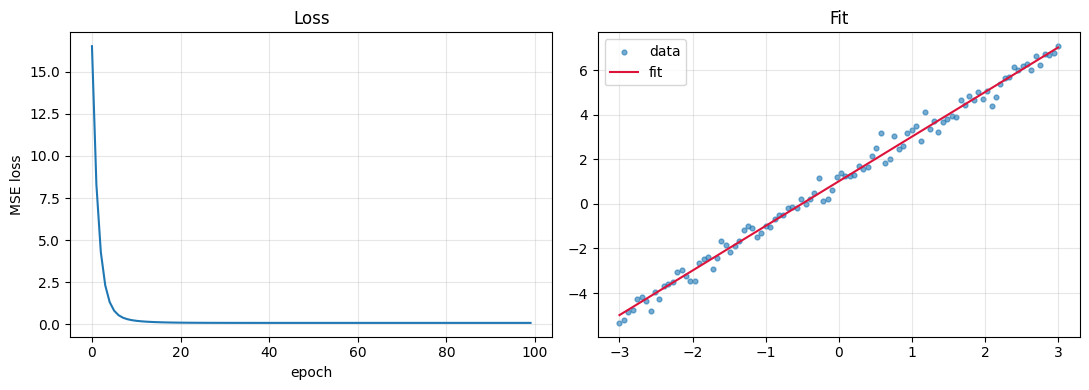

In [3]:
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# Noisy samples from the true relationship y = 2x + 1
x = torch.linspace(-3, 3, 100).unsqueeze(1)
y = 2 * x + 1 + 0.3 * torch.randn_like(x)

model = nn.Linear(1, 1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

losses = []
for epoch in range(100):
    y_pred = model(x)                 # 1. forward
    loss = loss_fn(y_pred, y)         # 2. loss
    optimizer.zero_grad()             # 3. clear gradients
    loss.backward()                   # 4. backward
    optimizer.step()                  # 5. update
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | loss = {loss.item():.4f}")

w = model.weight.item(); b = model.bias.item()
print(f"\nlearned: w = {w:.3f}, b = {b:.3f}   (true w=2, b=1)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(losses); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("MSE loss")
ax[0].set_title("Loss"); ax[0].grid(alpha=.3)
ax[1].scatter(x, y, s=12, alpha=.6, label="data")
ax[1].plot(x, model(x).detach(), c="crimson", label="fit")
ax[1].legend(); ax[1].set_title("Fit"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

Loss falls steeply and then flattens at a non-zero value. That floor is the noise in
the data (`0.3 * randn`) — it is not reducible, and a loss that reached zero would
mean the model had fitted the noise.

In the original session this converged to `w = 2.000, b = 1.011` with loss settling
near 0.095 — the true relationship recovered from noisy samples.

## 4. Experiment 1 — learning rate too large

Same code, one change: `lr` from 0.05 to 1.5.

In [4]:
torch.manual_seed(0)
model_big = nn.Linear(1, 1)
opt_big = torch.optim.SGD(model_big.parameters(), lr=1.5)   # was 0.05

for epoch in range(100):
    loss = loss_fn(model_big(x), y)
    opt_big.zero_grad(); loss.backward(); opt_big.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | loss = {loss.item():.4f}")

Epoch   0 | loss = 12.6524
Epoch  10 | loss = 22286984146786975744.0000
Epoch  20 | loss = inf
Epoch  30 | loss = inf
Epoch  40 | loss = inf
Epoch  50 | loss = nan
Epoch  60 | loss = nan
Epoch  70 | loss = nan
Epoch  80 | loss = nan
Epoch  90 | loss = nan


Observed in the original session:

```
Epoch   0 | loss = 16.5048
Epoch  10 | loss = 27969616480900743168.0000
Epoch  20 | loss = inf
Epoch  50 | loss = nan
```

**What happens.** Each step overshoots the minimum, landing further away than it
started; the next gradient is larger, so the next overshoot is larger. Within ten
epochs the loss reaches 2.8×10¹⁹, then `inf`, then `nan`.

**Practical value.** `nan` or a rising loss means *lower the learning rate* — first
instinct, before anything else. It is among the most common failure modes in
practice. (Day 5 meets the same principle in different clothing: fine-tuning a
pretrained backbone at too high a learning rate destroys the pretrained weights.)

## 5. Experiment 2 — model too simple

Back to `lr=0.05`, but the data is now a parabola: `y = x²`.

Epoch   0 | loss = 14.0015
Epoch  10 | loss = 8.1841
Epoch  20 | loss = 7.4768
Epoch  30 | loss = 7.3909
Epoch  40 | loss = 7.3804
Epoch  50 | loss = 7.3791
Epoch  60 | loss = 7.3790
Epoch  70 | loss = 7.3790
Epoch  80 | loss = 7.3790
Epoch  90 | loss = 7.3790

learned: w = -0.003, b = 3.110


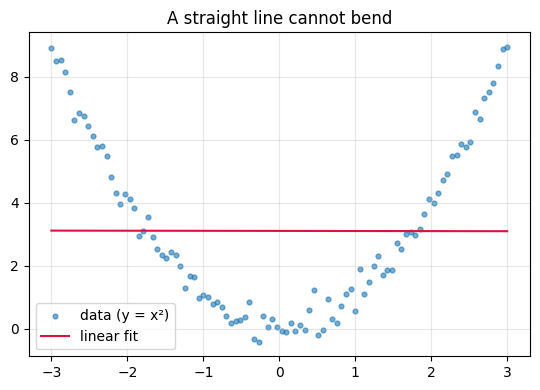

In [5]:
y_curve = x**2 + 0.3 * torch.randn_like(x)

torch.manual_seed(0)
model_lin = nn.Linear(1, 1)
opt_lin = torch.optim.SGD(model_lin.parameters(), lr=0.05)

for epoch in range(100):
    loss = loss_fn(model_lin(x), y_curve)
    opt_lin.zero_grad(); loss.backward(); opt_lin.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | loss = {loss.item():.4f}")

print(f"\nlearned: w = {model_lin.weight.item():.3f}, b = {model_lin.bias.item():.3f}")

plt.figure(figsize=(5.5, 4))
plt.scatter(x, y_curve, s=12, alpha=.6, label="data (y = x²)")
plt.plot(x, model_lin(x).detach(), c="crimson", label="linear fit")
plt.legend(); plt.grid(alpha=.3); plt.title("A straight line cannot bend")
plt.tight_layout(); plt.show()

Observed in the original session: loss falls to **7.3006 and stops**, with
`w = -0.000, b = 3.072` — a horizontal line through the middle of the data.

**What happens.** Training is working correctly; it found the least-bad straight line.
The floor at 7.3 is not an optimization failure but a **capacity ceiling**. A linear
model cannot represent a curved relationship, no matter how long it trains.

**Why this matters.** It is the reason non-linear activations exist. Without a ReLU
between them, two stacked `Linear` layers collapse algebraically into one:

```
y = (x·W₁ + b₁)·W₂ + b₂ = x·(W₁W₂) + (b₁W₂ + b₂) = x·W' + b'
```

So a network without activations is a linear model however deep it is, and hits
exactly this ceiling. Day 3 adds `nn.ReLU()` and measures the difference: roughly 92%
without it on MNIST versus 97.5% with it.

## Summary

- Tensors are NumPy arrays with a device, gradient tracking, and `float32` defaults.
- `backward()` computes gradients for every parameter automatically. Gradients
  accumulate, hence `zero_grad()`.
- The five-step loop — forward, loss, zero_grad, backward, step — is the whole of
  training, and does not change as models grow.
- **Learning rate too large → divergence to `nan`.** Diagnosis: lower it.
- **Model too simple → loss plateaus above the noise floor.** Diagnosis: more
  capacity, starting with non-linearity.

Those last two are the two failure modes on either side of a working model, and the
rest of this repo is largely about navigating between them.

**Next:** Day 3 applies this loop to a real classification task with 101,770
parameters, and adds the evaluation discipline (train/test split, confusion matrix,
overfitting check).